In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
house_data_df = pd.read_csv(
    "apartments_for_rent_classified_10K.csv", 
    sep=";",
    encoding="latin1",       
    engine="python",         
    on_bad_lines="skip"     
)

In [4]:
print(house_data_df.head())

           id                category  \
0  5668626895  housing/rent/apartment   
1  5664597177  housing/rent/apartment   
2  5668626833  housing/rent/apartment   
3  5659918074  housing/rent/apartment   
4  5668626759  housing/rent/apartment   

                                               title  \
0  Studio apartment 2nd St NE, Uhland Terrace NE,...   
1                  Studio apartment 814 Schutte Road   
2  Studio apartment N Scott St, 14th St N, Arling...   
3                     Studio apartment 1717 12th Ave   
4  Studio apartment Washington Blvd, N Cleveland ...   

                                                body amenities  bathrooms  \
0  This unit is located at second St NE, Uhland T...       NaN        NaN   
1  This unit is located at 814 Schutte Road, Evan...       NaN        NaN   
2  This unit is located at N Scott St, 14th St N,...       NaN        1.0   
3  This unit is located at 1717 12th Ave, Seattle...       NaN        1.0   
4  This unit is located at Wash

In [5]:
print(house_data_df.dtypes)

id                 int64
category             str
title                str
body                 str
amenities            str
bathrooms        float64
bedrooms         float64
currency             str
fee                  str
has_photo            str
pets_allowed         str
price              int64
price_display        str
price_type           str
square_feet        int64
address              str
cityname             str
state                str
latitude         float64
longitude        float64
source               str
time               int64
dtype: object


In [6]:
house_data_df['time'] = pd.to_datetime(house_data_df['time'], unit='s')

In [7]:
(house_data_df['time'].head())

0   2019-12-26 11:23:35
1   2019-12-22 12:17:43
2   2019-12-26 11:23:30
3   2019-12-18 11:15:43
4   2019-12-26 11:23:21
Name: time, dtype: datetime64[s]

In [8]:
house_data_df.isnull().sum()

id                  0
category            0
title               0
body                0
amenities        3549
bathrooms          34
bedrooms            7
currency            0
fee                 0
has_photo           0
pets_allowed     4163
price               0
price_display       0
price_type          0
square_feet         0
address          3327
cityname           77
state              77
latitude           10
longitude          10
source              0
time                0
dtype: int64

In [9]:
# turn amenities nulls into feature

house_data_df['has_amenities'] =  house_data_df['amenities'].notnull().astype(int)

In [10]:
house_data_df['has_amenities'].info

<bound method Series.info of 0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    1
9999    1
Name: has_amenities, Length: 10000, dtype: int64>

In [11]:
house_data_df['allow_pets'] = house_data_df['pets_allowed'].notnull().astype(int)

In [12]:
house_data_df.drop(['amenities', 'address', 'pets_allowed', 'source'], axis=1, inplace=True)

In [13]:
house_data_df.drop(['price_display','currency','price_type','title', 'has_photo'], axis=1, inplace=True)

In [14]:
house_data_df.info

<bound method DataFrame.info of               id                category  \
0     5668626895  housing/rent/apartment   
1     5664597177  housing/rent/apartment   
2     5668626833  housing/rent/apartment   
3     5659918074  housing/rent/apartment   
4     5668626759  housing/rent/apartment   
...          ...                     ...   
9995  5630240092  housing/rent/apartment   
9996  5668640983  housing/rent/apartment   
9997  5668643292  housing/rent/apartment   
9998  5668662559  housing/rent/apartment   
9999  5509132540  housing/rent/apartment   

                                                   body  bathrooms  bedrooms  \
0     This unit is located at second St NE, Uhland T...        NaN       0.0   
1     This unit is located at 814 Schutte Road, Evan...        NaN       1.0   
2     This unit is located at N Scott St, 14th St N,...        1.0       0.0   
3     This unit is located at 1717 12th Ave, Seattle...        1.0       0.0   
4     This unit is located at Washingto

In [15]:
duplicated_count = house_data_df.duplicated().sum()
print(duplicated_count)

0


In [16]:
house_data_df.columns

Index(['id', 'category', 'body', 'bathrooms', 'bedrooms', 'fee', 'price',
       'square_feet', 'cityname', 'state', 'latitude', 'longitude', 'time',
       'has_amenities', 'allow_pets'],
      dtype='str')

In [18]:
house_data_df['price_per_sqft'] = house_data_df['price'] / house_data_df['square_feet']

## Analysis

In [19]:
house_data_df.shape

(10000, 16)

In [20]:
house_data_df['category'].value_counts()

category
housing/rent/apartment     9996
housing/rent/home             2
housing/rent/short_term       2
Name: count, dtype: int64

In [21]:
# the top (most frequent) cities

top_cities = house_data_df['cityname'].value_counts().head(10).reset_index(name='count')
top_cities

,cityname,count
0,Austin,523
1,Dallas,216
2,Houston,186
3,San Antonio,182
4,Los Angeles,165
5,Chicago,148
6,Madison,121
7,Portland,113
8,Denver,105
9,San Francisco,104


## Bathrooms and Bedrooms Distribution

In [32]:
bathroom_count = house_data_df['bathrooms'].value_counts()

bathroom_pct = house_data_df['bathrooms'].value_counts(normalize=True)*100

distribution_bathrooms_df = pd.DataFrame({'Total Properties': bathroom_count, 'Percentage (%)' :bathroom_pct})
distribution_bathrooms_df

,Total Properties,Percentage (%)
bathrooms,,
1.0,6639,66.616496
2.0,2418,24.262492
2.5,315,3.160747
1.5,282,2.829621
3.0,174,1.745936
3.5,66,0.662252
4.0,46,0.461569
4.5,12,0.120409
5.0,8,0.080273


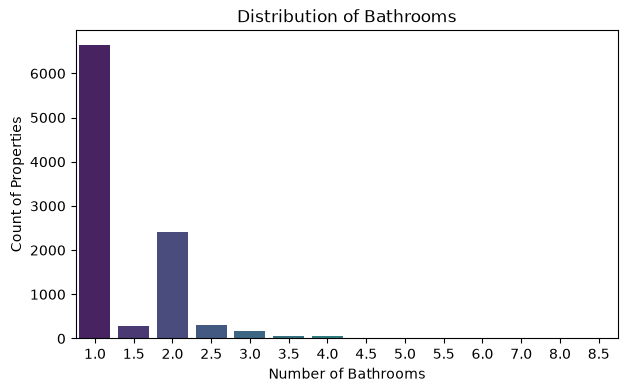

In [27]:
plt.figure(figsize=(7,4))
sns.countplot(data=house_data_df, x='bathrooms', palette='viridis')

plt.title('Distribution of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count of Properties')
plt.show()

In [28]:
bedroom_count = house_data_df['bedrooms'].value_counts()

bedroom_pct = house_data_df['bedrooms'].value_counts(normalize=True)*100

distribution_bedrooms_df = pd.DataFrame({'Total Properties': bedroom_count, 'Percentage (%)' :bedroom_pct})
distribution_bedrooms_df

,Total Properties,Percentage (%)
bedrooms,,
1.0,4607,46.102272
2.0,3398,34.003803
3.0,1276,12.768938
4.0,404,4.042830
0.0,198,1.981387
5.0,89,0.890623
6.0,15,0.150105
7.0,3,0.030021
8.0,2,0.020014


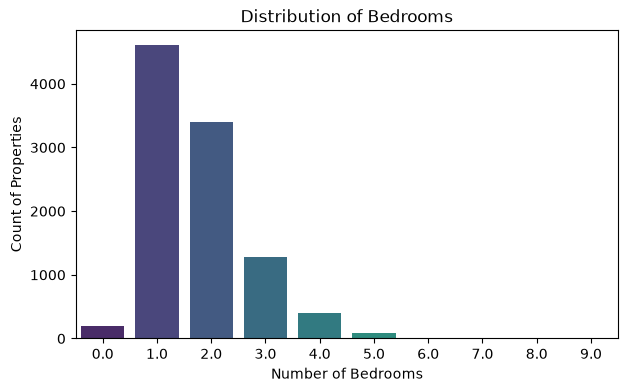

In [29]:
plt.figure(figsize=(7,4))
sns.countplot(data=house_data_df, x='bedrooms', palette='viridis')

plt.title('Distribution of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count of Properties')
plt.show()

## Exploring Prices

In [31]:
summary_of_price = house_data_df['price'].agg(['min','max','mean','median'])

summary_of_price

min         200.0000
max       52500.0000
mean       1486.2775
median     1270.0000
Name: price, dtype: float64

In [30]:
top_cities_pricepersqfeet = house_data_df.groupby('cityname')['price_per_sqft'].mean().sort_values(ascending=False).head(10)
top_cities_pricepersqfeet

cityname
Barstow          37.023977
New Bern          7.800000
Dania Beach       7.500000
Pacifica          7.200000
San Francisco     6.165010
Studio City       5.320000
Moorpark          5.240000
Lake Balboa       5.020000
Sausalito         4.916393
Palo Alto         4.784645
Name: price_per_sqft, dtype: float64

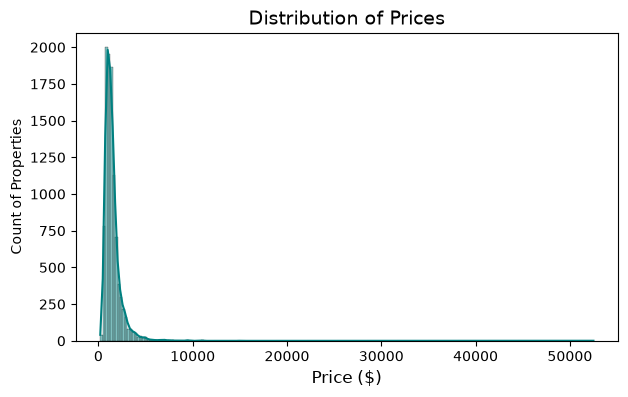

In [54]:
plt.figure(figsize=(7, 4)) 
sns.histplot(data=house_data_df, x="price", kde=True, color="teal")

plt.title("Distribution of Prices", fontsize=14)
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Count of Properties", fontsize=10)
plt.show()


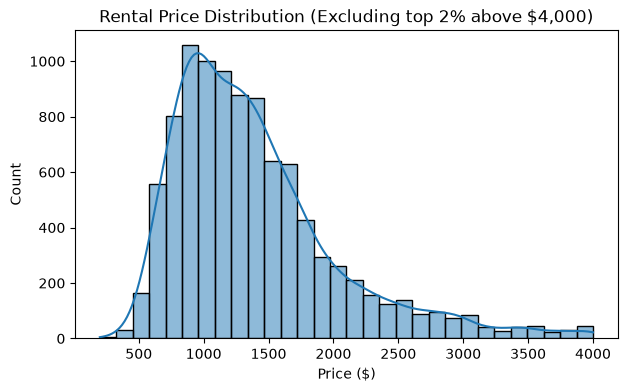

In [56]:
q_cutoff = house_data_df["price"].quantile(0.98)

typical_rentals = house_data_df[house_data_df["price"] <= q_cutoff]

plt.figure(figsize=(7, 4)) 
sns.histplot(data=typical_rentals, x="price", kde=True, bins=30)

plt.title(f"Rental Price Distribution (Excluding top 2% above ${q_cutoff:,.0f})")
plt.xlabel("Price ($)")
plt.show()

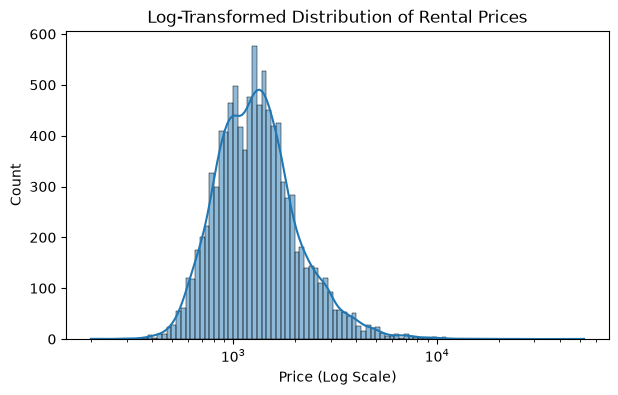

In [57]:
plt.figure(figsize=(7, 4)) 
sns.histplot(data=house_data_df, x="price", log_scale=True, kde=True)

plt.title("Log-Transformed Distribution of Rental Prices")
plt.xlabel("Price (Log Scale)")
plt.show()


In [58]:
print(f"Most Common Price (Mode): ${house_data_df['price'].mode()[0]:,.2f}")
print(f"Middle Market Price (Median): ${house_data_df['price'].median():,.2f}")
print(f"Average Price (Mean - Skeptical): ${house_data_df['price'].mean():,.2f}")
print(f"Top 5% Luxury Threshold: ${house_data_df['price'].quantile(0.95):,.2f}")

Most Common Price (Mode): $1,350.00
Middle Market Price (Median): $1,270.00
Average Price (Mean - Skeptical): $1,486.28
Top 5% Luxury Threshold: $2,995.00


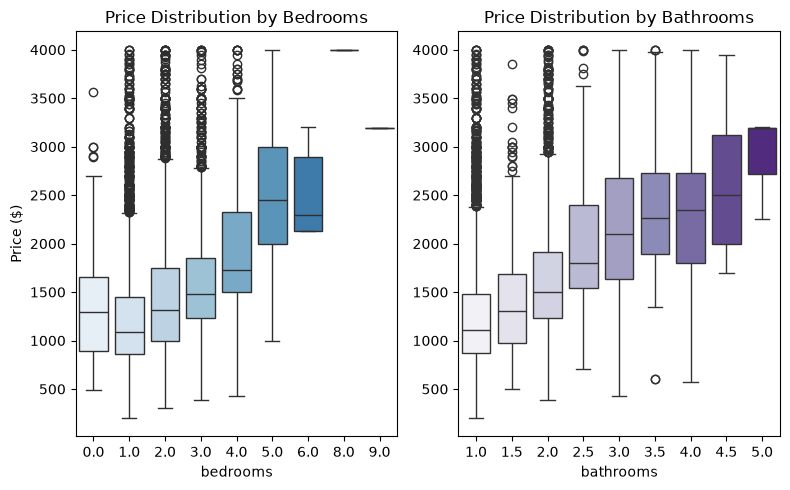

In [60]:
q_cutoff = house_data_df["price"].quantile(0.98)
df_filtered = house_data_df[house_data_df["price"] <= q_cutoff]

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# Bedrooms Boxplot
sns.boxplot(data=df_filtered, x="bedrooms", y="price", ax=axes[0], palette="Blues")
axes[0].set_title("Price Distribution by Bedrooms")
axes[0].set_ylabel("Price ($)")

# Bathrooms Boxplot
sns.boxplot(data=df_filtered, x="bathrooms", y="price", ax=axes[1], palette="Purples")
axes[1].set_title("Price Distribution by Bathrooms")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

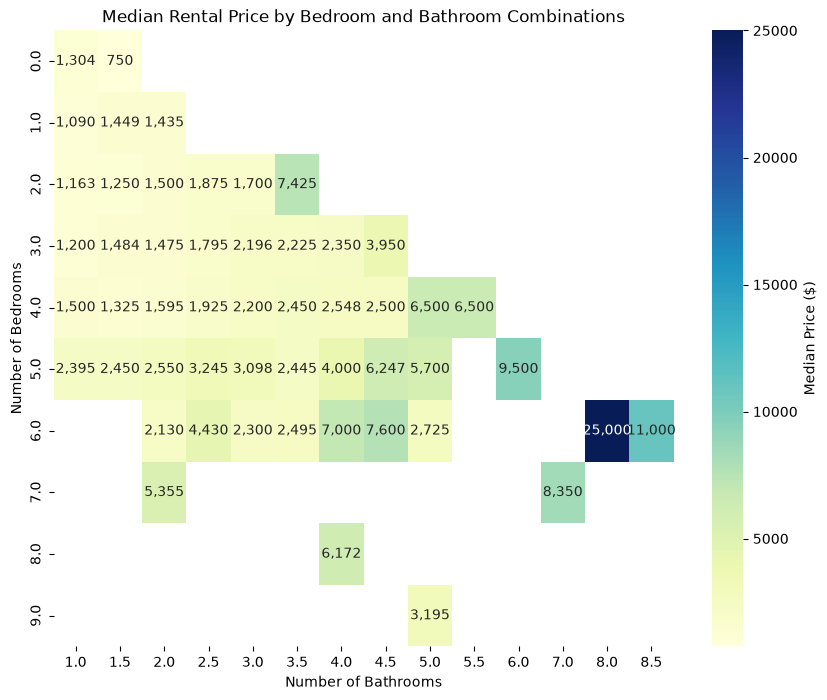

In [62]:
pivot_table = house_data_df.pivot_table(
    values="price", index="bedrooms", columns="bathrooms", aggfunc=np.median
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=",.0f", cmap="YlGnBu", cbar_kws={'label': 'Median Price ($)'})

plt.title("Median Rental Price by Bedroom and Bathroom Combinations")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Bedrooms")
plt.show()

In [50]:
amenities_pct = house_data_df['has_amenities'].value_counts(normalize=True)*100
amenities_pct

has_amenities
1    64.51
0    35.49
Name: proportion, dtype: float64

In [51]:
pets_pct = house_data_df['allow_pets'].value_counts(normalize=True)*100
pets_pct

allow_pets
1    58.37
0    41.63
Name: proportion, dtype: float64

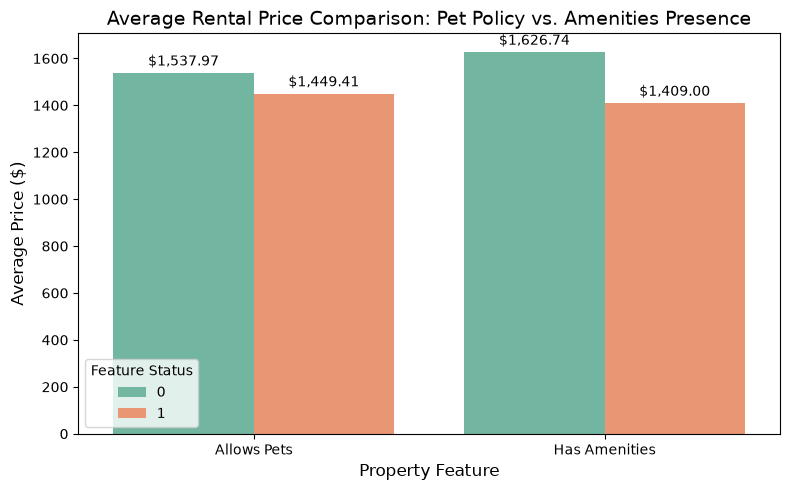

In [65]:
df_subset = house_data_df[["price", "allow_pets", "has_amenities"]].copy()

df_long = pd.melt(
    df_subset, 
    id_vars=["price"], 
    value_vars=["allow_pets", "has_amenities"],
    var_name="Feature", 
    value_name="Status"
)

df_long["Feature"] = df_long["Feature"].replace({
    "allow_pets": "Allows Pets", 
    "has_amenities": "Has Amenities"
})
df_long["Status"] = df_long["Status"].replace({True: "Yes", False: "No"})

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_long, 
    x="Feature", 
    y="price", 
    hue="Status", 
    estimator="mean", # Calculates average
    errorbar=None,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="${:,.2f}", padding=3)

plt.title("Average Rental Price Comparison: Pet Policy vs. Amenities Presence", fontsize=14)
plt.xlabel("Property Feature", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.legend(title="Feature Status")
plt.tight_layout()
plt.show()


## Mapping Hotspots

<function matplotlib.pyplot.show(close=None, block=None)>

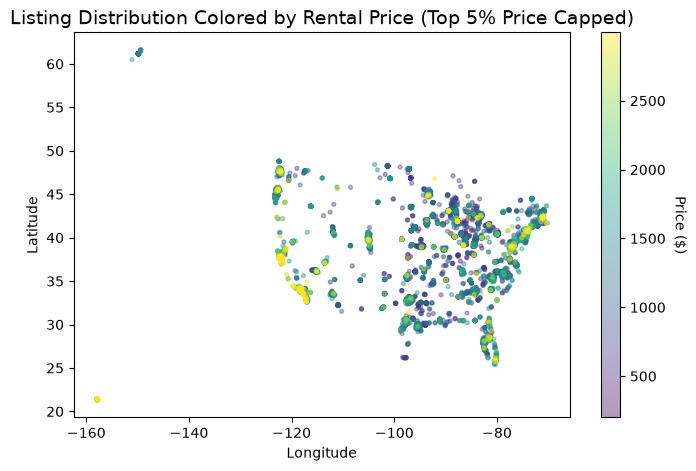

In [67]:
plt.figure(figsize=(8, 5))

price_cap = house_data_df["price"].quantile(0.95)

points = plt.scatter(
    x=house_data_df["longitude"],
    y=house_data_df["latitude"],
    c=house_data_df["price"],
    cmap="viridis",
    s=8,
    alpha=0.4,
    vmax=price_cap
)

cbar = plt.colorbar(points)
cbar.set_label("Price ($)", rotation=270, labelpad=15)

plt.title("Listing Distribution Colored by Rental Price (Top 5% Price Capped)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show

In [68]:
house_data_df['year'] = house_data_df['time'].dt.year
house_data_df['year_month'] = house_data_df['time'].dt.to_period('M')

In [69]:
monthly_trends = house_data_df.groupby('year_month')['price'].agg(['mean', 'std', 'count']).reset_index()

monthly_trends['year_month'] = monthly_trends['year_month'].dt.to_timestamp()

print(monthly_trends)

  year_month         mean          std  count
0 2019-09-01  1520.422582   801.166278   2719
1 2019-10-01  1548.800000   853.354323     15
2 2019-11-01  1792.689655  1838.551625     29
3 2019-12-01  1472.091474  1159.638217   7237


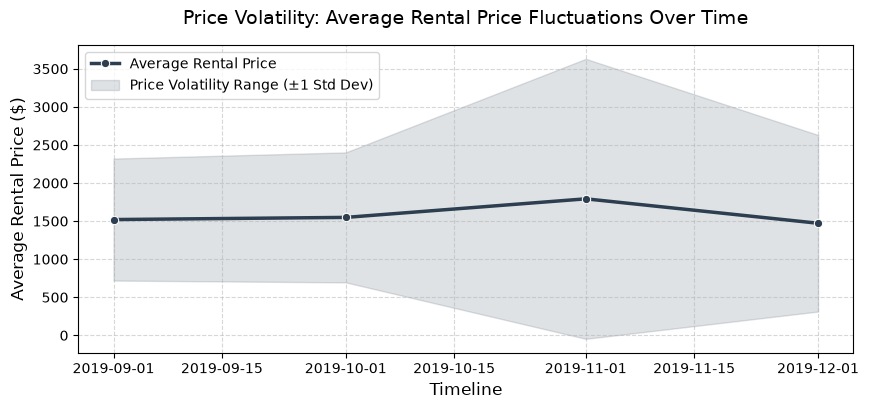

In [72]:
plt.figure(figsize=(10, 4))

# Plot the average rental price trend line
sns.lineplot(
    data=monthly_trends, 
    x='year_month', 
    y='mean', 
    marker='o', 
    color='#2c3e50', 
    linewidth=2.5, 
    label='Average Rental Price'
)

# Optional: Add a shaded area showing standard deviation (price spread/variance)
plt.fill_between(
    monthly_trends['year_month'], 
    monthly_trends['mean'] - monthly_trends['std'], 
    monthly_trends['mean'] + monthly_trends['std'], 
    color='#2c3e50', 
    alpha=0.15, 
    label='Price Volatility Range (±1 Std Dev)'
)

plt.title('Price Volatility: Average Rental Price Fluctuations Over Time', fontsize=14, pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Average Rental Price ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.show()


In [35]:
house_data_df.columns

Index(['id', 'category', 'body', 'bathrooms', 'bedrooms', 'fee', 'price',
       'square_feet', 'cityname', 'state', 'latitude', 'longitude', 'time',
       'has_amenities', 'allow_pets', 'price_per_sqft'],
      dtype='str')

In [39]:
house_data_df.dtypes

id                        int64
category                    str
body                        str
bathrooms               float64
bedrooms                float64
fee                         str
price                     int64
square_feet               int64
cityname                    str
state                       str
latitude                float64
longitude               float64
time              datetime64[s]
has_amenities             int64
allow_pets                int64
price_per_sqft          float64
dtype: object

In [41]:
house_data_df.to_parquet('cleaned_data.parquet', engine='fastparquet')